# 실습 2-3 : 의사결정나무

#### **<실습 내용>**

1. 의사결정나무 회귀 (Regression)
- Day 2-1의 콘크리트 데이터를 사용하여 **선형 회귀와 성능 비교**
- 나무 시각화 및 max_depth에 따른 과적합 확인

2. 의사결정나무 분류 (Classification)
- Day 2-2의 제조 데이터를 사용하여 **로지스틱 회귀와 성능 비교**
- 나무 시각화 및 max_depth에 따른 과적합 확인
- 가지치기 (사전/사후)

3. 하이퍼 파라미터 최적화
- Grid Search를 통한 최적 파라미터 탐색

## 분석 준비

### 주요 라이브러리 호출

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, confusion_matrix, precision_score,
                             recall_score, f1_score)

# 그래프에 한글이 깨지거나(경고: Glyph ... missing from font(s) DejaVu Sans) 안 보이는 문제 방지
# Windows 기본 한글 폰트인 '맑은 고딕(Malgun Gothic)'으로 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False   # 한글 폰트 사용 시 마이너스(-) 기호가 깨지는 문제 방지

## 1) 의사결정나무 회귀 (Regression)

> **의사결정나무(Decision Tree)** 는 입력변수 공간을 반복적으로 분할하여 예측 규칙을 나무 형태로 만드는 모델임
> - 분류와 회귀 모두에 사용할 수 있으며, 회귀 나무는 지니 불순도 대신 **분산(Variance)** 을 기준으로 노드를 분할함
> - 끝 노드에 속하는 학습 데이터들의 **평균값**을 예측값으로 사용함
> - Day 2-1에서 학습한 선형 회귀와 동일한 데이터로 성능을 비교함

### 1-1) 데이터 준비

> Day 2-1에서 사용한 콘크리트 압축강도 데이터를 동일하게 사용함

In [7]:
Concrete_data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2-3_reg_data.csv"))

In [8]:
# 입출력 변수 분할
Y_reg = Concrete_data["Concrete_compressive_strength"]
X_reg = Concrete_data.drop(["Concrete_compressive_strength"], axis=1)

# 학습/테스트 데이터 분할 (Day 2-1과 동일한 random_state 사용)
X_reg_train, X_reg_test, Y_reg_train, Y_reg_test = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=0)

print("학습 데이터 크기   :", X_reg_train.shape, Y_reg_train.shape)
print("테스트 데이터 크기 :", X_reg_test.shape, Y_reg_test.shape)

학습 데이터 크기   : (721, 8) (721,)
테스트 데이터 크기 : (309, 8) (309,)


In [9]:
# 회귀 모형 성능 지표 산출 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % (mean_squared_error(true, pred)))
    print("RMSE      : %.3f" % (np.sqrt(mean_squared_error(true, pred))))
    print("MAE       : %.3f" % (mean_absolute_error(true, pred)))
    print("R-squared : %.3f" % (r2_score(true, pred)))

### 1-2) 모델 학습

In [10]:
DT_reg1 = DecisionTreeRegressor()
DT_reg1.fit(X_reg_train, Y_reg_train)
DT_reg1_pred = DT_reg1.predict(X_reg_test)

print("=== 의사결정나무 회귀 ===")
get_regscore(Y_reg_test, DT_reg1_pred)
print()
print("=== Day 2-1 다중선형회귀 참고 성능 ===")
print("RMSE      : 9.676")
print("R-squared : 0.635")

=== 의사결정나무 회귀 ===
MSE       : 55.846
RMSE      : 7.473
MAE       : 4.814
R-squared : 0.782

=== Day 2-1 다중선형회귀 참고 성능 ===
RMSE      : 9.676
R-squared : 0.635


### 1-3) 나무 시각화

> 회귀 나무에서는 각 끝 노드의 **value**가 해당 영역 데이터의 평균 예측값을 의미함

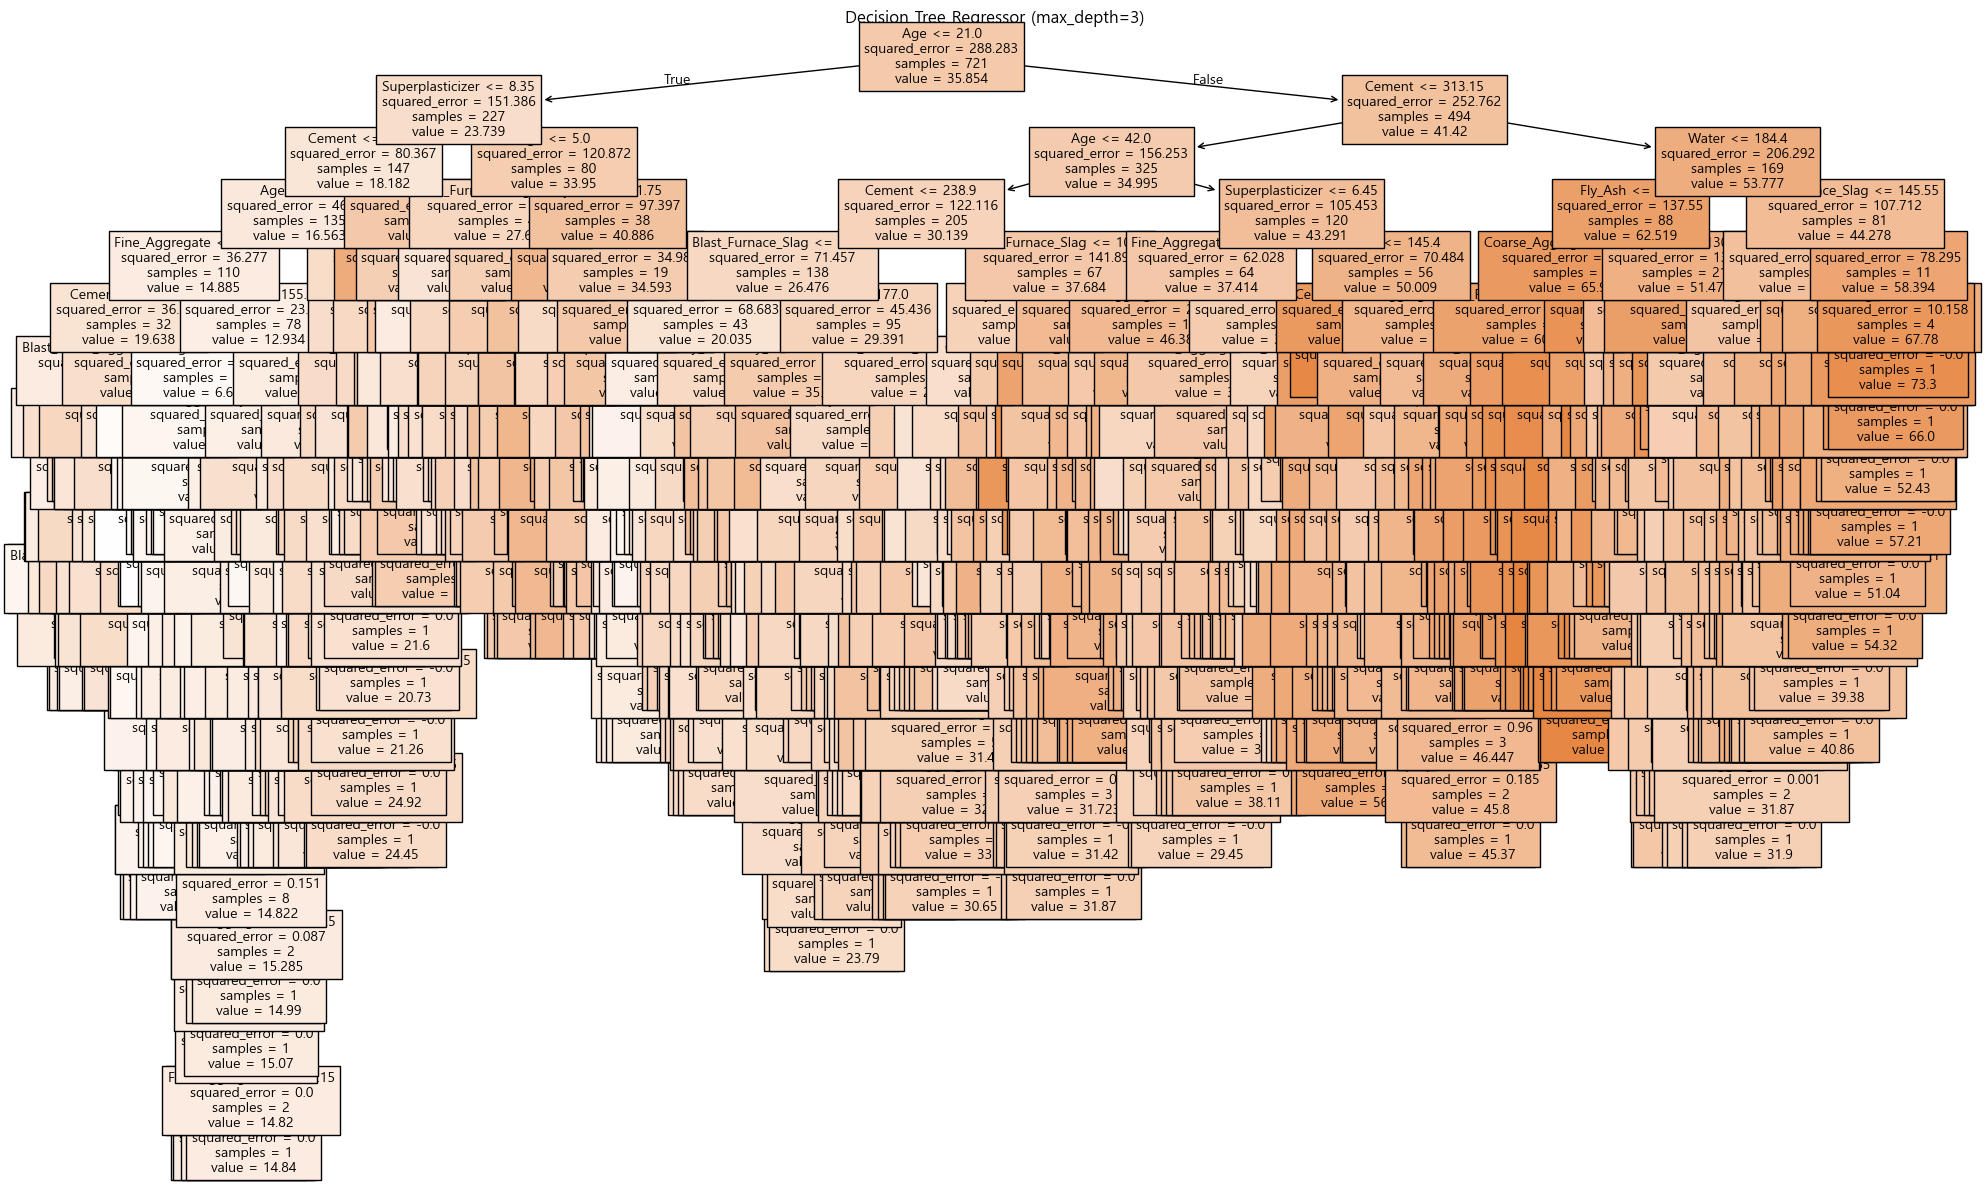

In [11]:
plt.figure(figsize=(20, 12))
tree.plot_tree(DT_reg1, filled=True, feature_names=X_reg.columns, fontsize=10)
plt.title("Decision Tree Regressor (max_depth=3)")
plt.tight_layout()
plt.show()

### 1-4) 예측 시각화

> 대각선(빨간 점선)에 가까울수록 예측이 정확함. 선형 회귀와 달리 의사결정나무는 끝 노드 개수만큼의 계단 형태 예측값을 가짐

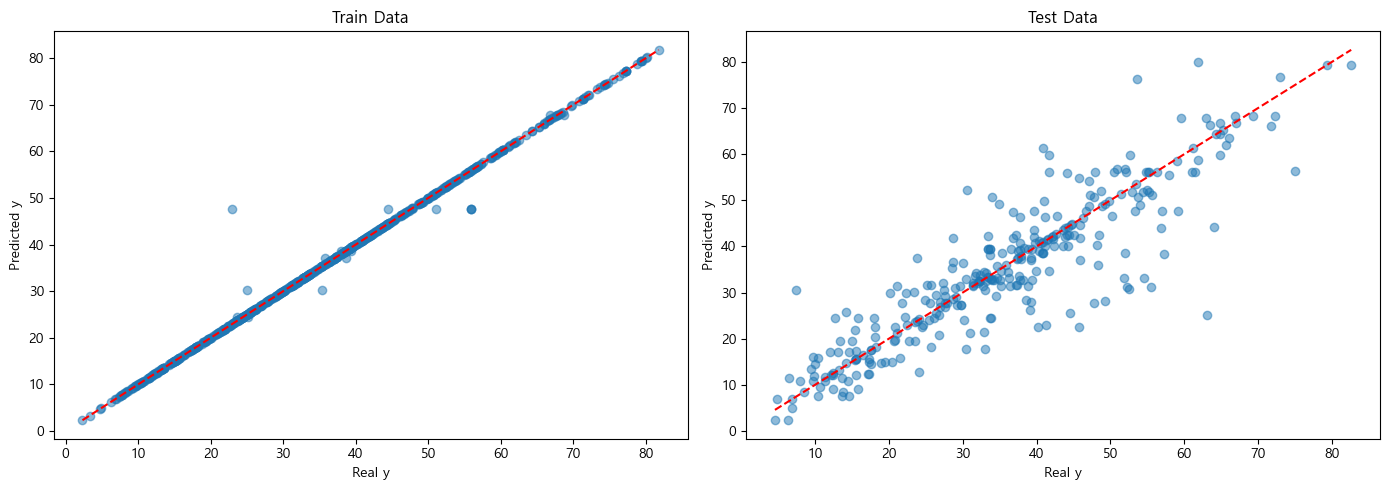

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(Y_reg_train, DT_reg1.predict(X_reg_train), alpha=0.5)
axes[0].plot([Y_reg_train.min(), Y_reg_train.max()],
             [Y_reg_train.min(), Y_reg_train.max()], "r--")
axes[0].set_xlabel("Real y")
axes[0].set_ylabel("Predicted y")
axes[0].set_title("Train Data")

axes[1].scatter(Y_reg_test, DT_reg1_pred, alpha=0.5)
axes[1].plot([Y_reg_test.min(), Y_reg_test.max()],
             [Y_reg_test.min(), Y_reg_test.max()], "r--")
axes[1].set_xlabel("Real y")
axes[1].set_ylabel("Predicted y")
axes[1].set_title("Test Data")

plt.tight_layout()
plt.show()

### 1-5) max_depth에 따른 과적합 확인

> 나무가 과하게 깊어지면(max_depth가 커지면) 학습 데이터에 **과적합**되어 테스트 데이터의 성능이 떨어질 수 있음

In [13]:
DT_reg2 = DecisionTreeRegressor(random_state=0, max_depth=10)
DT_reg2.fit(X_reg_train, Y_reg_train)
DT_reg2_pred = DT_reg2.predict(X_reg_test)

DT_reg3 = DecisionTreeRegressor(random_state=0, max_depth=5)
DT_reg3.fit(X_reg_train, Y_reg_train)
DT_reg3_pred = DT_reg3.predict(X_reg_test)

print("=== max_depth=None ===")
get_regscore(Y_reg_test, DT_reg1_pred)
print()
print("=== max_depth=10 ===")
get_regscore(Y_reg_test, DT_reg2_pred)
print()
print("=== max_depth=5 ===")
get_regscore(Y_reg_test, DT_reg3_pred)
print()
print("=== Day 2-1 다중선형회귀 참고 ===")
print("RMSE      : 9.676")
print("R-squared : 0.635")

=== max_depth=None ===
MSE       : 55.846
RMSE      : 7.473
MAE       : 4.814
R-squared : 0.782

=== max_depth=10 ===
MSE       : 56.136
RMSE      : 7.492
MAE       : 4.900
R-squared : 0.781

=== max_depth=5 ===
MSE       : 82.974
RMSE      : 9.109
MAE       : 6.894
R-squared : 0.677

=== Day 2-1 다중선형회귀 참고 ===
RMSE      : 9.676
R-squared : 0.635


---

## 2) 의사결정나무 분류 (Classification)

> 의사결정나무 **분류**에서는 **지니 불순도(Gini Impurity)** 를 기준으로 데이터를 가장 잘 구분하는 입력변수와 경계 값을 선택함
> - $Gini(S) = 1 - \sum_{i=1}^{c} p_i^2$ (불순도가 0이면 완벽히 분류된 상태)
> - **정보 이득(Information Gain)** 이 가장 큰 변수로 노드를 분할함
> - Day 2-2에서 학습한 로지스틱 회귀와 동일한 데이터로 성능을 비교함

### 2-1) 데이터 준비

> Day 2-2에서 사용한 제조 불량 데이터를 동일하게 사용함

In [14]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2-3_cls_data.csv"))

#MF_Data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/day2-3_data.csv")

# 입출력 변수 분할
Y = MF_Data["Failure"]
X = MF_Data.drop(["Failure"], axis=1)

# 범주형 변수 처리
X["Measure2"] = X["Measure2"].astype("category")
X["Measure3"] = X["Measure3"].astype("category")
X = pd.get_dummies(X)
data_columns = X.columns

# 출력변수 값 변경
Y = Y.replace({"No": 0, "Yes": 1}).astype(int)

# 학습/테스트 데이터 분할
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0, stratify=Y)

print("학습 데이터 크기   :", X_train.shape, Y_train.shape)
print("테스트 데이터 크기 :", X_test.shape, Y_test.shape)

학습 데이터 크기   : (5530, 31) (5530,)
테스트 데이터 크기 : (2370, 31) (2370,)


C:\Users\Admin\AppData\Local\Temp\ipykernel_2544\3403311988.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = Y.replace({"No": 0, "Yes": 1}).astype(int)


In [15]:
# 분류 모형 성능 지표 산출 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % (accuracy_score(real, pred)))
    print("Precision : %.3f" % (precision_score(real, pred)))
    print("Recall    : %.3f" % (recall_score(real, pred)))
    print("F1-score  : %.3f" % (f1_score(real, pred)))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

### 2-2) 모델 학습

In [16]:
DT_cla1 = DecisionTreeClassifier()
DT_cla1.fit(X_train, Y_train)
DT_cla1_pred = DT_cla1.predict(X_test)
get_classscore(Y_test, DT_cla1_pred)

Accuracy  : 0.995
Precision : 0.696
Recall    : 0.727
F1-score  : 0.711

혼동행렬
[[2341    7]
 [   6   16]]


### 2-3) 나무 시각화

> 의사결정나무의 큰 장점은 모델의 **분류 규칙을 직관적으로 이해**할 수 있다는 것임

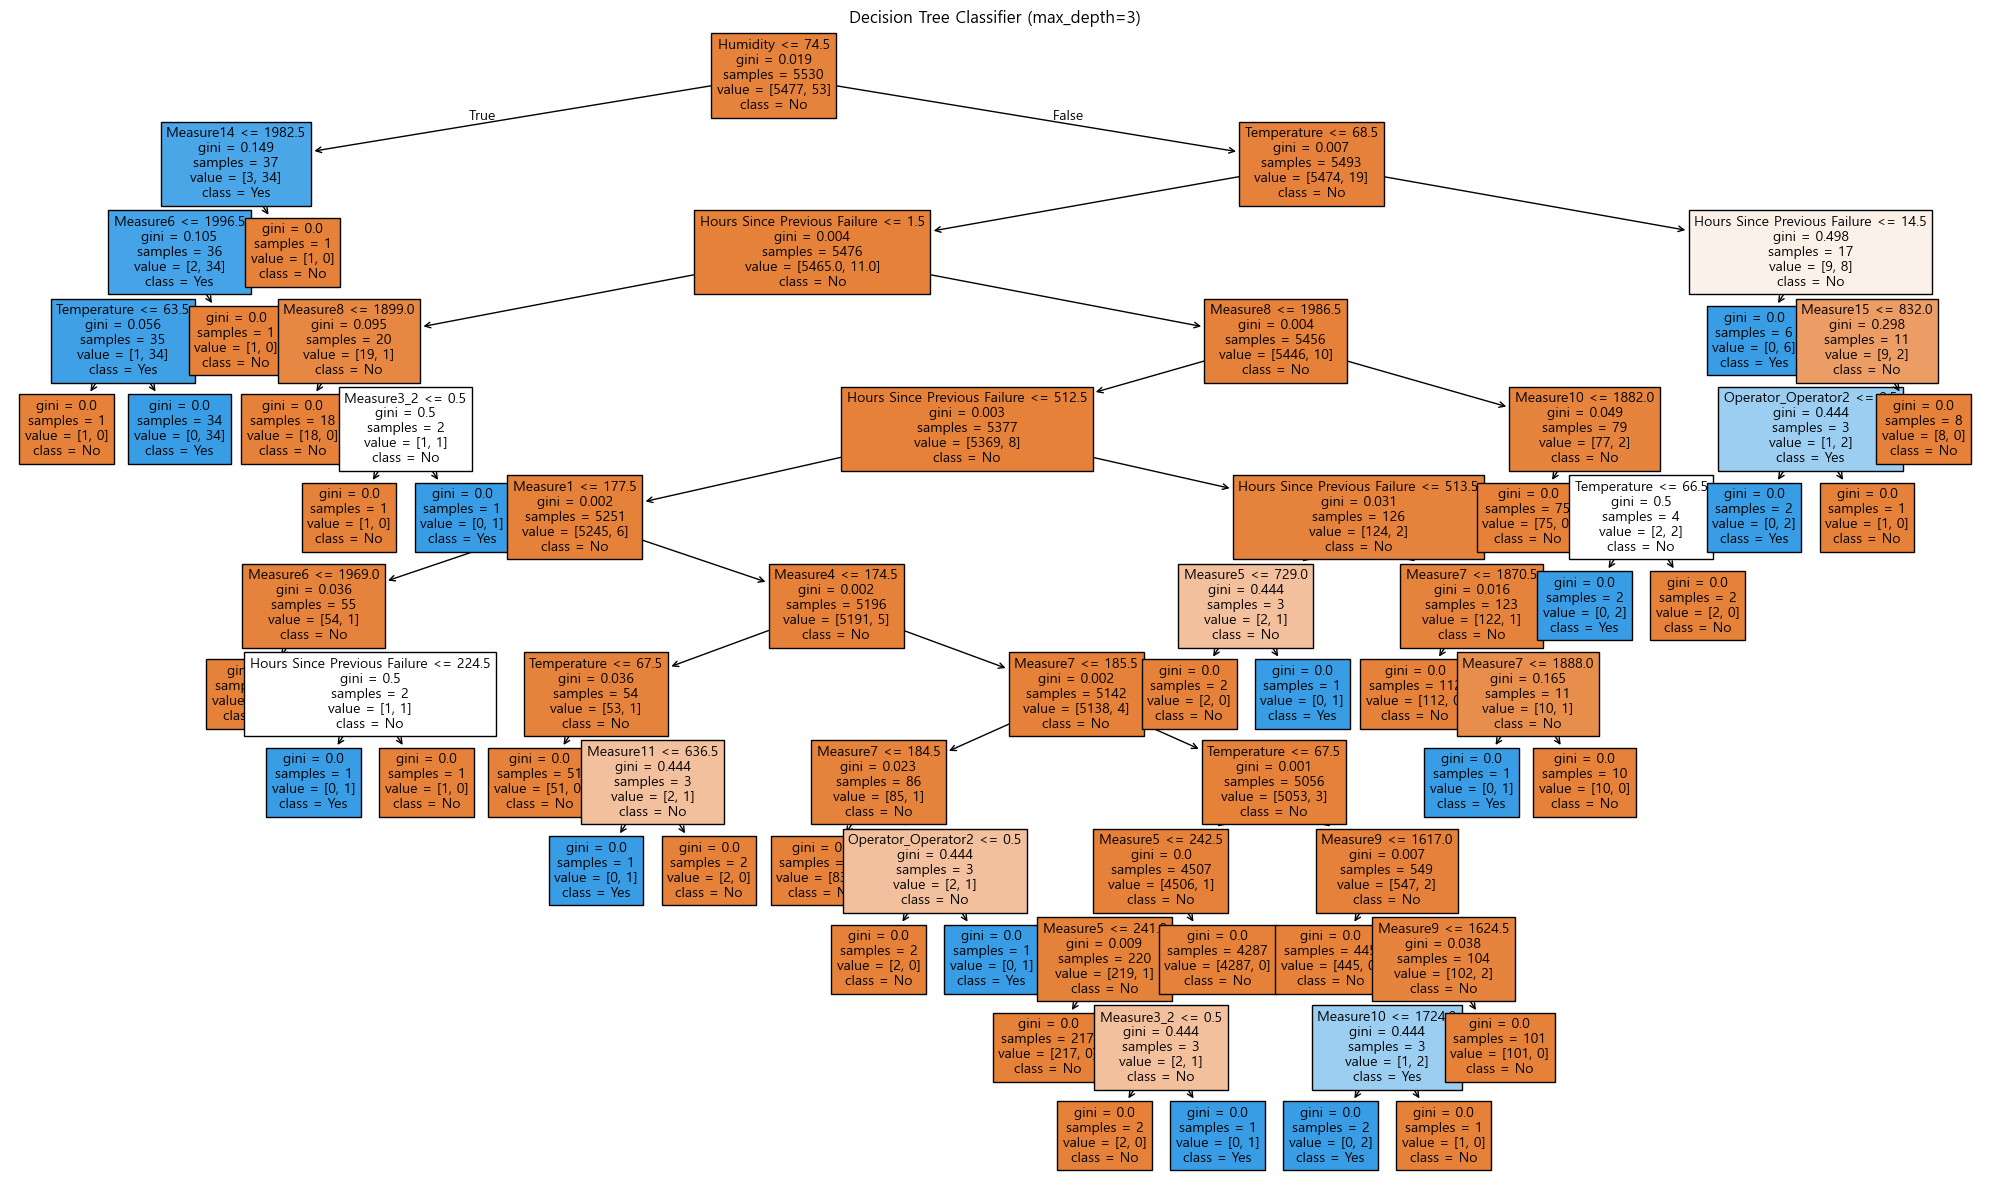

In [17]:
plt.figure(figsize=(20, 12))
tree.plot_tree(DT_cla1, class_names=["No", "Yes"],
               filled=True, feature_names=data_columns, fontsize=10)
plt.title("Decision Tree Classifier (max_depth=3)")
plt.tight_layout()
plt.show()

### 2-4) max_depth에 따른 과적합 확인

> 나무가 깊어지면(max_depth가 커지면) 학습 데이터에 **과적합**되어 테스트 데이터의 성능이 떨어질 수 있음
> - **사전 가지치기**: max_depth, max_leaf_nodes, min_samples_leaf 등을 설정하여 나무 성장을 제한
> - **사후 가지치기**: 완성된 나무에서 유의미하지 않은 가지를 제거 (ccp_alpha 사용)

In [18]:
# max_depth=10으로 변경
DT_cla2 = DecisionTreeClassifier(max_depth=10)
DT_cla2.fit(X_train, Y_train)
DT_cla2_pred = DT_cla2.predict(X_test)

print("=== max_depth=None ===")
get_classscore(Y_test, DT_cla1_pred)
print()
print("=== max_depth=10 ===")
get_classscore(Y_test, DT_cla2_pred)

=== max_depth=None ===
Accuracy  : 0.995
Precision : 0.696
Recall    : 0.727
F1-score  : 0.711

혼동행렬
[[2341    7]
 [   6   16]]

=== max_depth=10 ===
Accuracy  : 0.994
Precision : 0.667
Recall    : 0.727
F1-score  : 0.696

혼동행렬
[[2340    8]
 [   6   16]]


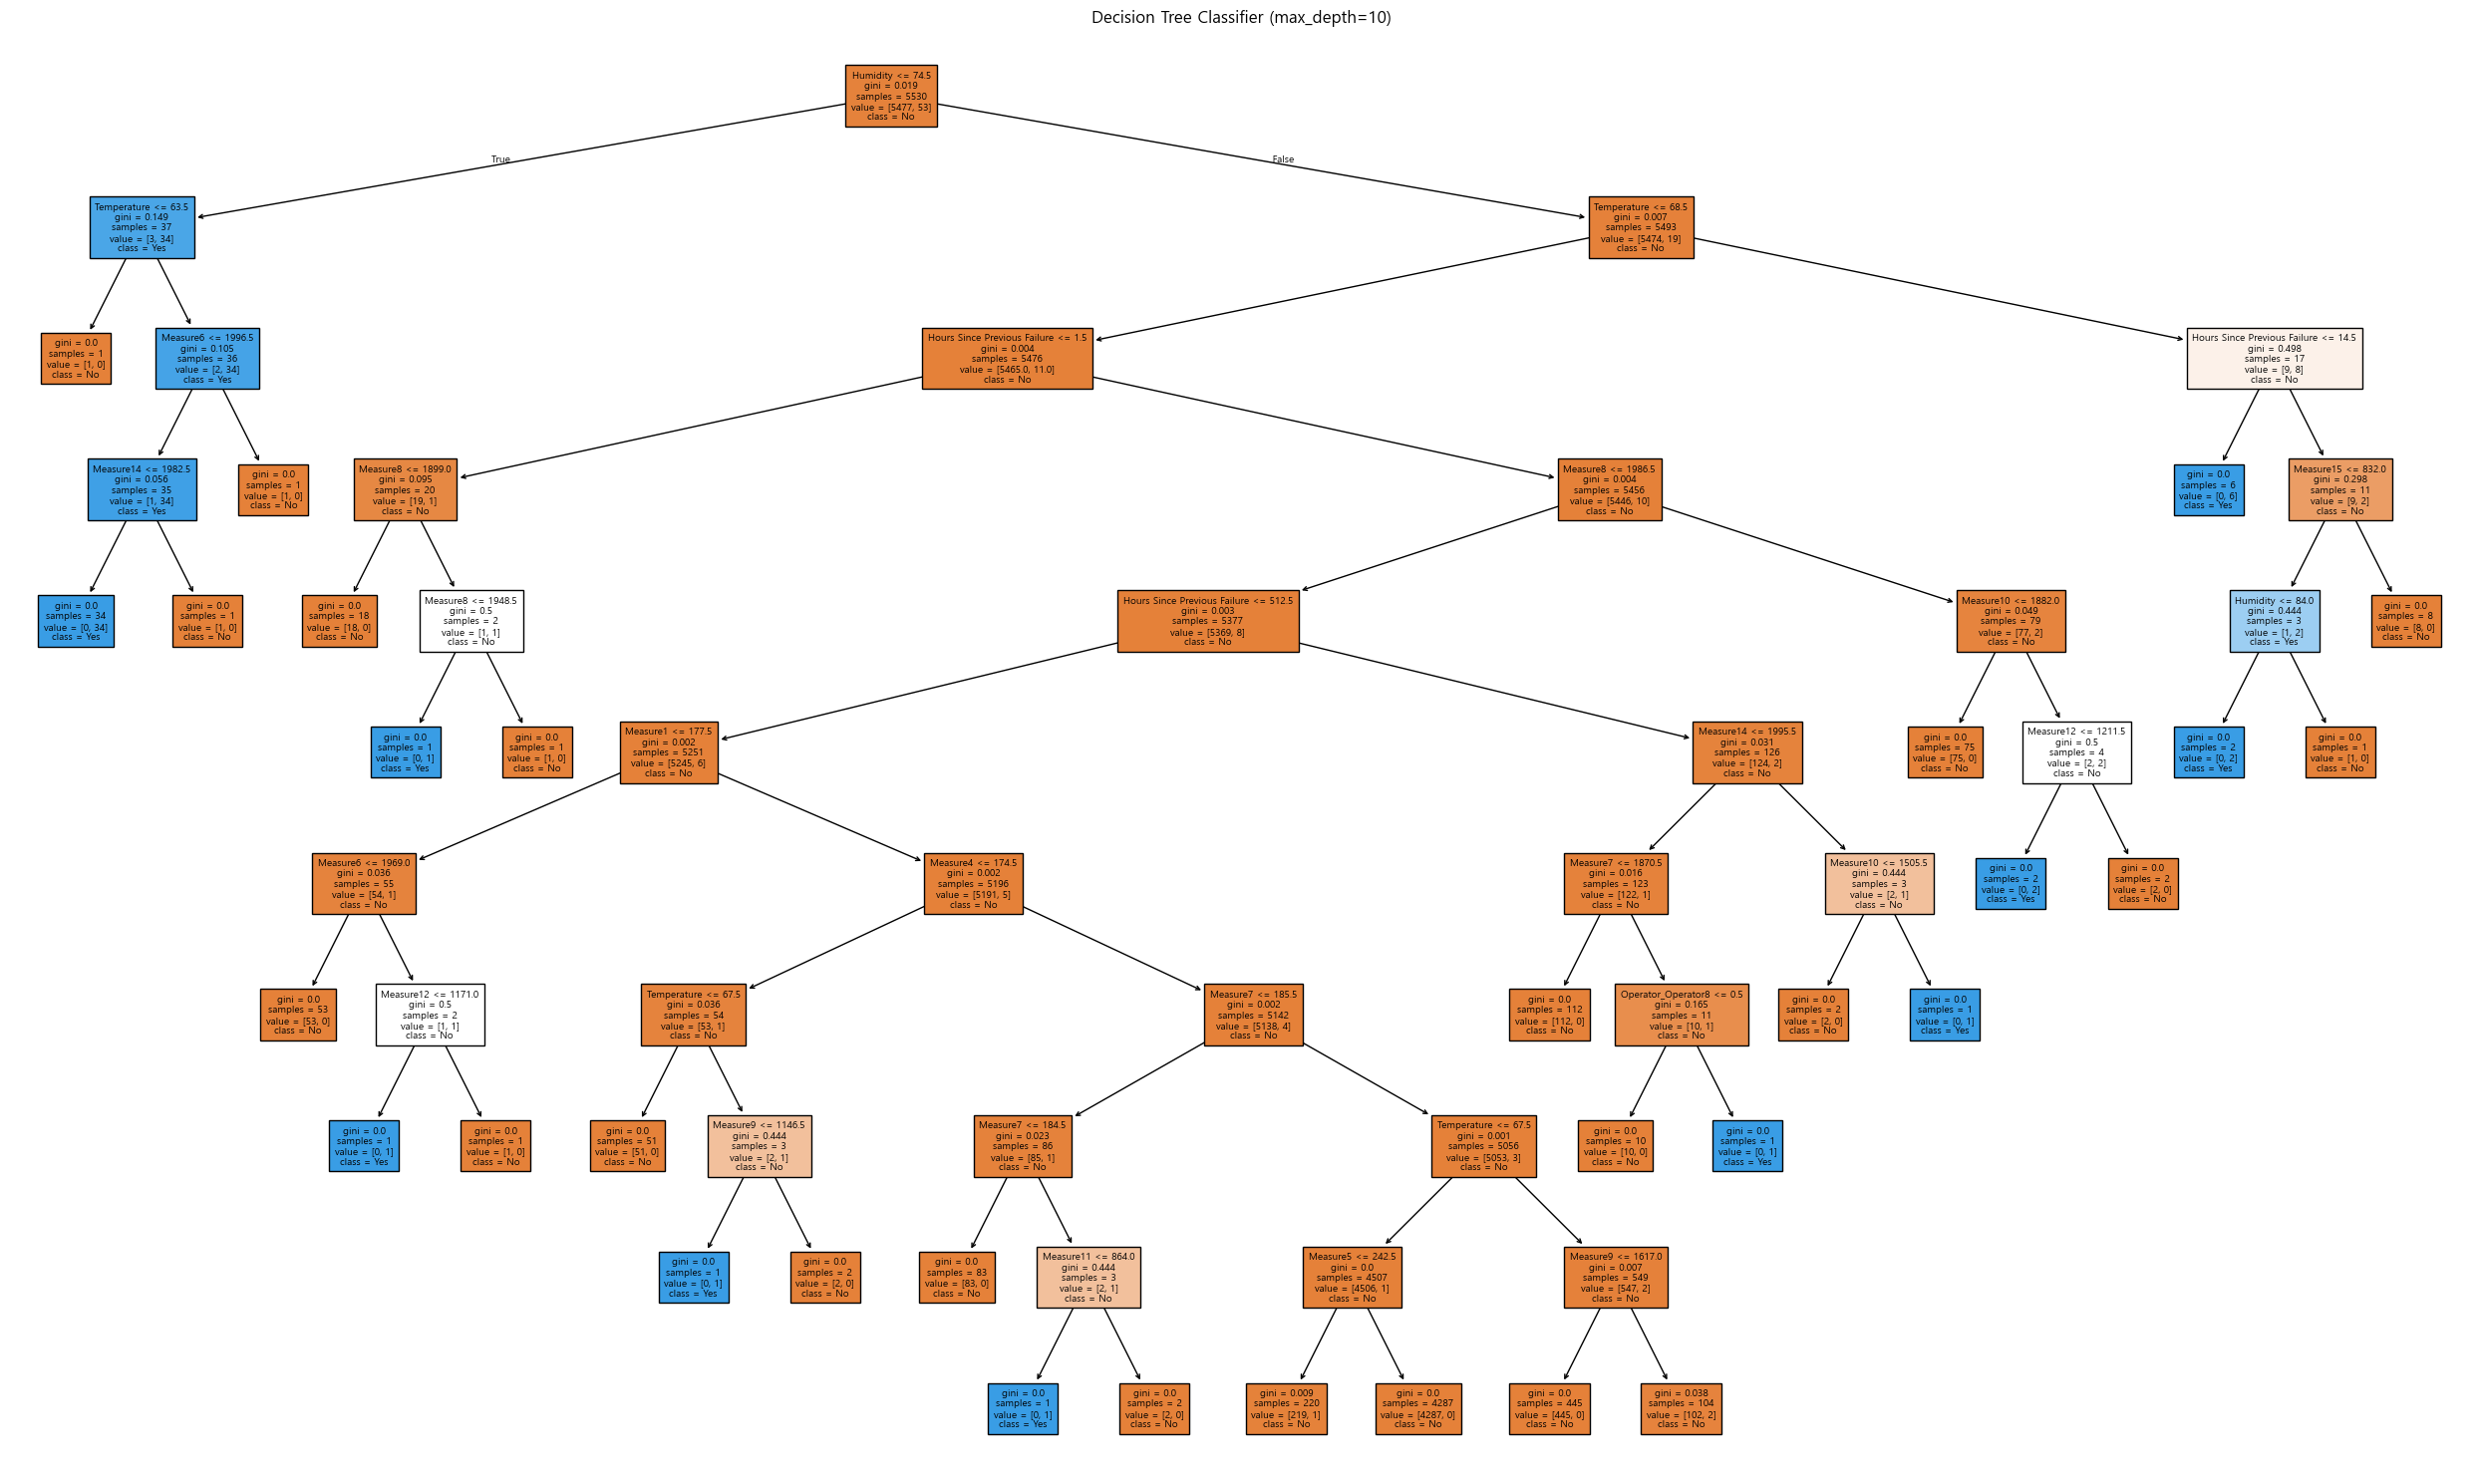

In [19]:
# 나무 시각화 (복잡한 나무)
plt.figure(figsize=(25, 15))
tree.plot_tree(DT_cla2, class_names=["No", "Yes"],
               filled=True, feature_names=data_columns, fontsize=7)
plt.title("Decision Tree Classifier (max_depth=10)")
plt.tight_layout()
plt.show()

In [20]:
depth_cla = DT_cla1.get_depth()
depth_cla

12

### 2-5) 가지치기를 통한 과적합 방지

> max_depth=10 모델은 과적합되어 F1 Score가 크게 떨어졌음
> - **사전 가지치기**: min_samples_leaf를 설정하여 나무 성장을 제한
> - **사후 가지치기**: ccp_alpha를 사용하여 완성된 나무에서 불필요한 가지를 제거

In [ ]:
# 사전 가지치기
#DT_cla2 = DecisionTreeClassifier(max_depth=10)
DT_pre = DecisionTreeClassifier(max_depth=10, min_samples_leaf=3)
DT_pre.fit(X_train, Y_train)
DT_pre_pred = DT_pre.predict(X_test)

print("=== 사전 가지치기 (max_depth=10, min_samples_leaf=5) ===")
get_classscore(Y_test, DT_pre_pred)

=== 사전 가지치기 (max_depth=10, min_samples_leaf=5) ===
Accuracy  : 0.996
Precision : 0.882
Recall    : 0.682
F1-score  : 0.769

혼동행렬
[[2346    2]
 [   7   15]]


> ccp_alpha는 비교하고자 하는 성능지표가 가장 높은 지점을 선택하며, alpha가 너무 크면 나무가 과도하게 잘려 underfitting됨

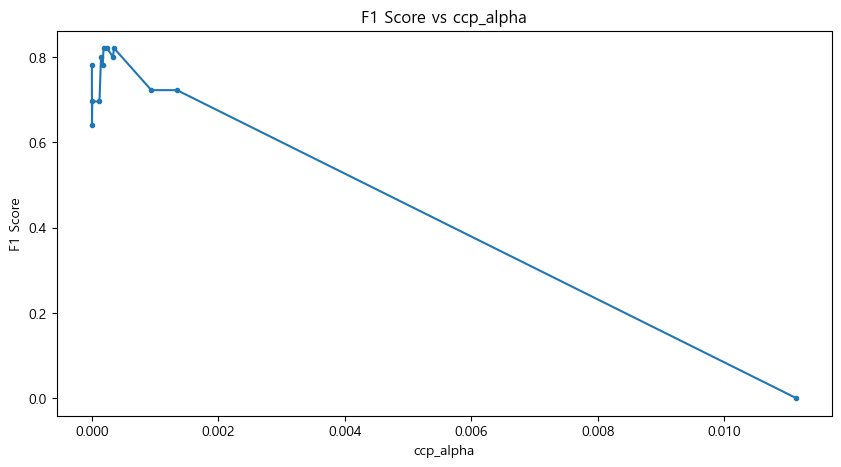

최적 ccp_alpha: 0.00018

=== 사전 가지치기  ===
Accuracy  : 0.996
Precision : 0.882
Recall    : 0.682
F1-score  : 0.769

혼동행렬
[[2346    2]
 [   7   15]]

=== 사후 가지치기 (ccp_alpha=0.00018) ===
Accuracy  : 0.997
Precision : 0.941
Recall    : 0.727
F1-score  : 0.821

혼동행렬
[[2347    1]
 [   6   16]]


In [22]:
# 사후 가지치기: ccp_alpha별 테스트 F1 score 비교
path = DT_cla2.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas

f1_scores = []
for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(ccp_alpha=alpha)
    dt.fit(X_train, Y_train)
    pred = dt.predict(X_test)
    f1_scores.append(f1_score(Y_test, pred))

plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, f1_scores, marker="o", markersize=3)
plt.xlabel("ccp_alpha")
plt.ylabel("F1 Score")
plt.title("F1 Score vs ccp_alpha")
plt.show()

best_idx = np.argmax(f1_scores)
print("최적 ccp_alpha:", round(ccp_alphas[best_idx], 5))

# 최적 ccp_alpha로 모델 학습 및 성능 비교
best_alpha = ccp_alphas[best_idx]
DT_post = DecisionTreeClassifier(ccp_alpha=best_alpha)
DT_post.fit(X_train, Y_train)
DT_post_pred = DT_post.predict(X_test)

print("\n=== 사전 가지치기  ===")
get_classscore(Y_test, DT_pre_pred)
print()
print(f"=== 사후 가지치기 (ccp_alpha={best_alpha:.5f}) ===")
get_classscore(Y_test, DT_post_pred)

---

## 3) 하이퍼 파라미터 최적화

> 의사결정나무의 주요 하이퍼 파라미터:
>
> | 파라미터 | 의미 |
> |:---:|:---:|
> | max_depth | 트리의 최대 깊이 |
> | max_leaf_nodes | 끝 노드(Leaf)의 최대 개수 |
> | min_samples_leaf | 끝 노드가 되기 위한 최소 샘플 수 |
> | min_samples_split | 노드를 분할하기 위한 최소 샘플 수 |
> | ccp_alpha | 사후 가지치기 강도 (값이 클수록 가지를 많이 제거) |

### 3-1) Grid Search

> **Grid Search**는 하이퍼 파라미터의 모든 조합을 탐색하여 최적의 조합을 찾는 방법임

In [23]:
from sklearn.model_selection import ParameterGrid

# 하이퍼파라미터 그리드 설정
params = {
    "max_depth": range(1, 20, 5),
    "min_samples_leaf": [6, 8, 10],
    "min_samples_split": [6, 8, 10],
    "ccp_alpha": [0, 0.001, 0.005, 0.01]
}

param_grid = list(ParameterGrid(params))
score_list = []

for param in param_grid:
    dt = DecisionTreeClassifier(**param)
    dt.fit(X_train, Y_train)
    y_pred = dt.predict(X_test)
    score = f1_score(Y_test, y_pred)
    score_list.append(score)

print("최적의 하이퍼파라미터:", param_grid[np.argmax(score_list)])
print("최적의 성능 (F1 score):", np.round(np.max(score_list), 4))

최적의 하이퍼파라미터: {'ccp_alpha': 0, 'max_depth': 6, 'min_samples_leaf': 8, 'min_samples_split': 6}
최적의 성능 (F1 score): 0.8293


### 3-2) 최적 모델 학습

In [24]:
# 최적 하이퍼파라미터로 모델 재학습
best_params = param_grid[np.argmax(score_list)]

DT_best = DecisionTreeClassifier(**best_params)
DT_best.fit(X_train, Y_train)
DT_best_predict = DT_best.predict(X_test)
get_classscore(Y_test, DT_best_predict)

Accuracy  : 0.997
Precision : 0.895
Recall    : 0.773
F1-score  : 0.829

혼동행렬
[[2346    2]
 [   5   17]]


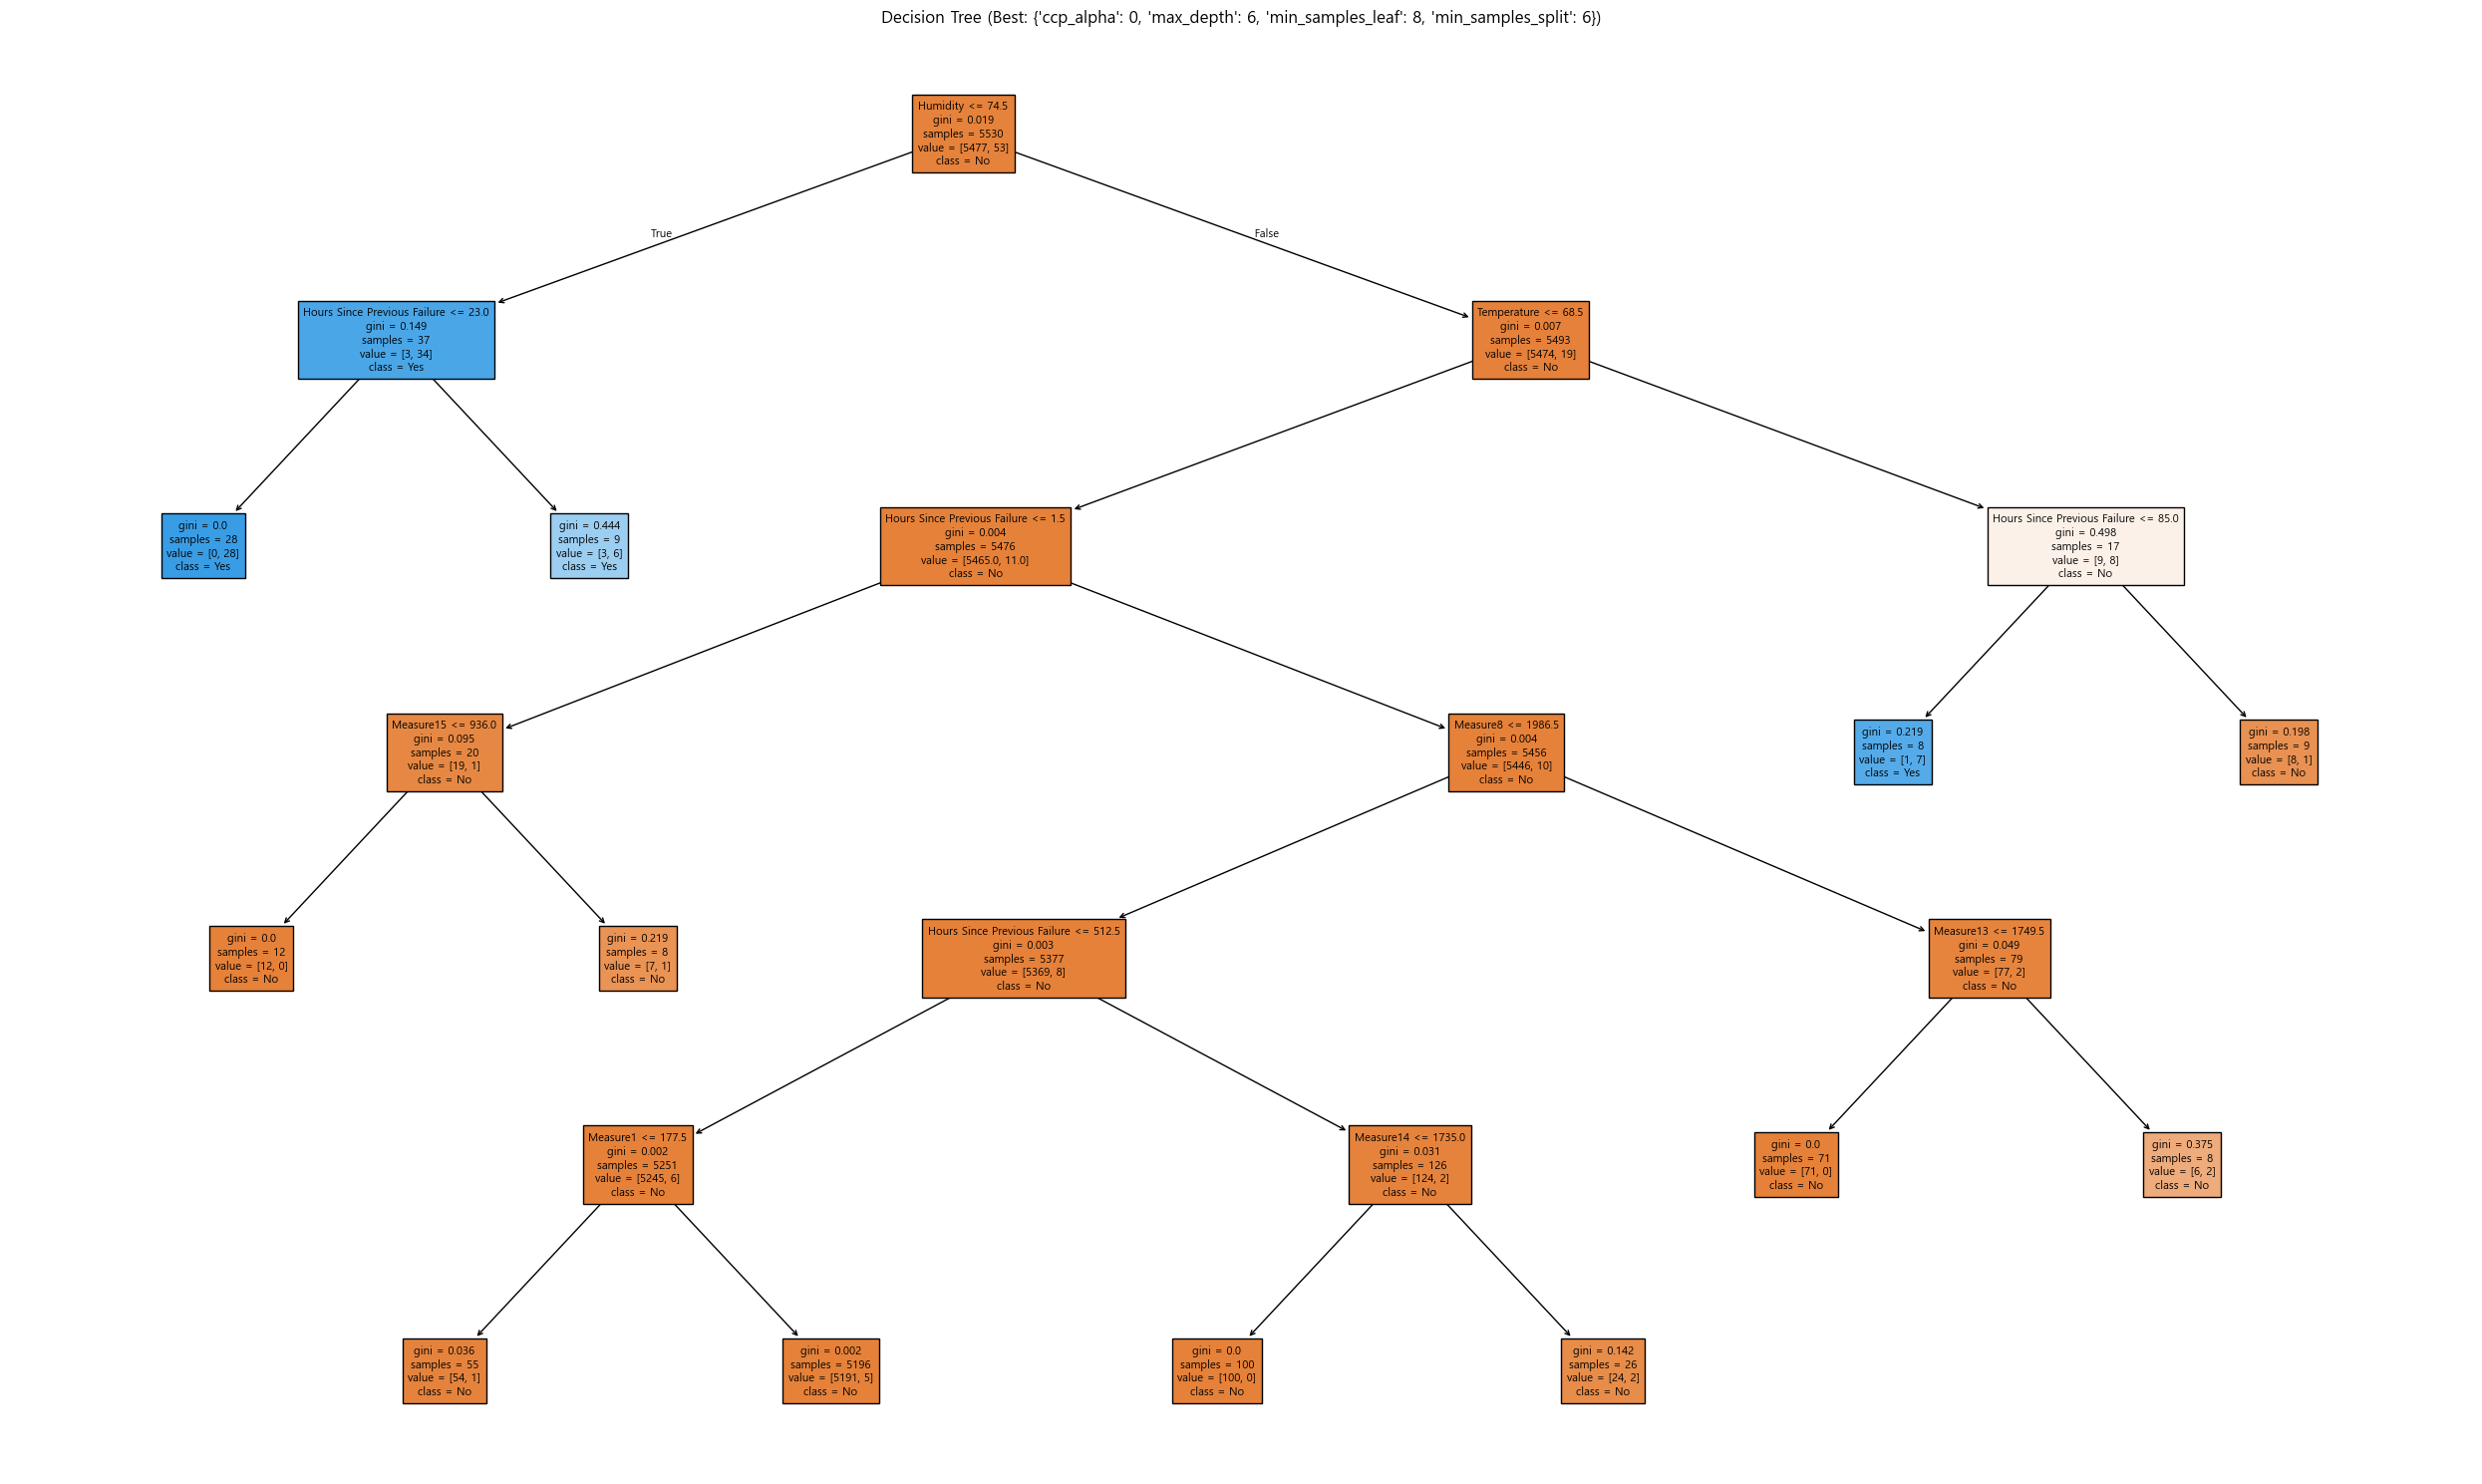

In [25]:
# 최적 모델 나무 시각화
plt.figure(figsize=(25, 15))
tree.plot_tree(DT_best, class_names=["No", "Yes"],
               filled=True, feature_names=data_columns, fontsize=8)
plt.title(f"Decision Tree (Best: {best_params})")
plt.tight_layout()
plt.show()

---

## 4) Vibe Coding 실습

### 4-1) 회귀 / 분류 나무 심화

**[과제 1]** 지수는 회귀 나무 모델의 깊이가 너무 깊어지면 과적합이 발생할 수 있다는 점을 알게 되었습니다. AI와 함께 적절한 트리 깊이를 찾는 방법을 알아보고, 다양한 깊이에서의 성능을 비교하여 가장 적절한 깊이를 찾아보세요.

In [26]:
# [과제 1] 회귀 나무의 적절한 트리 깊이 찾기
# max_depth를 1부터 늘려가며 Train / Test / 교차검증(CV) 성능을 비교
from sklearn.model_selection import cross_val_score

depths = range(1, 21)
rows = []
for d in depths:
    dt = DecisionTreeRegressor(random_state=0, max_depth=d)
    dt.fit(X_reg_train, Y_reg_train)

    train_r2 = dt.score(X_reg_train, Y_reg_train)     # 학습 데이터 R2
    test_r2 = dt.score(X_reg_test, Y_reg_test)        # 테스트 데이터 R2
    cv_r2 = cross_val_score(dt, X_reg_train, Y_reg_train,
                            cv=5, scoring="r2").mean() # 5-겹 교차검증 R2

    rows.append({"max_depth": d, "Train_R2": train_r2,
                 "Test_R2": test_r2, "CV_R2": cv_r2})

depth_df = pd.DataFrame(rows).round(3)

# 과적합에 강건한 기준인 교차검증 R2가 가장 높은 깊이를 최적 깊이로 선택
best_depth = int(depth_df.loc[depth_df["CV_R2"].idxmax(), "max_depth"])
print("최적 max_depth (CV_R2 기준):", best_depth)
depth_df

최적 max_depth (CV_R2 기준): 12


,max_depth,Train_R2,Test_R2,CV_R2
0,1,0.234,0.285,0.204
1,2,0.485,0.406,0.433
2,3,0.653,0.562,0.603
3,4,0.758,0.617,0.668
4,5,0.845,0.677,0.712
5,6,0.902,0.731,0.759
6,7,0.943,0.762,0.780
7,8,0.968,0.771,0.786
8,9,0.980,0.773,0.781
9,10,0.988,0.781,0.779


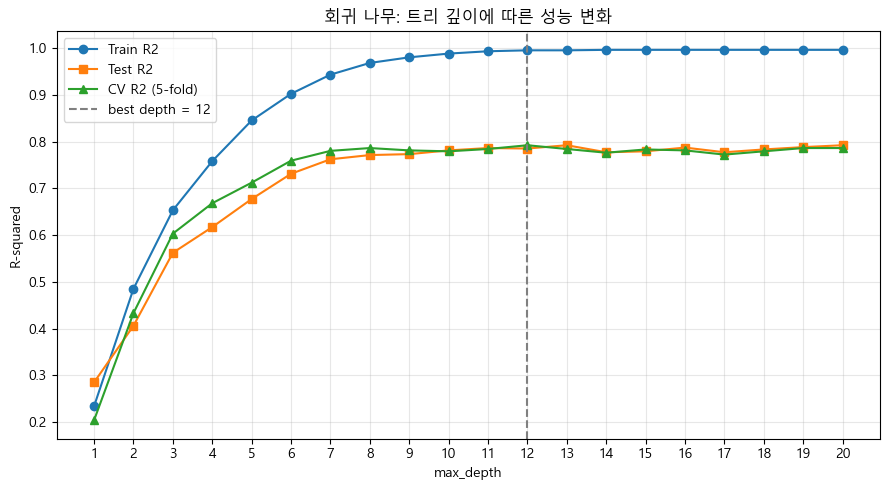

[최적 깊이 12] 테스트 성능
MSE       : 55.101
RMSE      : 7.423
MAE       : 4.729
R-squared : 0.785


In [27]:
# 깊이에 따른 성능 곡선
# Train R2는 깊이가 깊어질수록 계속 오르지만, CV/Test R2는 특정 깊이 이후 정체·하락 → 과적합 구간
plt.figure(figsize=(9, 5))
plt.plot(depth_df["max_depth"], depth_df["Train_R2"], marker="o", label="Train R2")
plt.plot(depth_df["max_depth"], depth_df["Test_R2"], marker="s", label="Test R2")
plt.plot(depth_df["max_depth"], depth_df["CV_R2"], marker="^", label="CV R2 (5-fold)")
plt.axvline(x=best_depth, color="gray", linestyle="--", label=f"best depth = {best_depth}")
plt.xlabel("max_depth")
plt.ylabel("R-squared")
plt.title("회귀 나무: 트리 깊이에 따른 성능 변화")
plt.xticks(list(depths))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 최적 깊이로 최종 모델 학습 및 평가
DT_reg_best = DecisionTreeRegressor(random_state=0, max_depth=best_depth)
DT_reg_best.fit(X_reg_train, Y_reg_train)
DT_reg_best_pred = DT_reg_best.predict(X_reg_test)

print(f"[최적 깊이 {best_depth}] 테스트 성능")
get_regscore(Y_reg_test, DT_reg_best_pred)

### 4-2) 모델 결과 해석 심화

**[과제 2]** 지수는 회귀 나무와 분류 나무가 어떤 변수를 중요하게 사용하여 데이터를 분할하는지 궁금해졌습니다. AI와 함께 각 모델의 주요 변수를 확인하고, 해당 변수가 중요한 이유를 분할 기준 및 변수명과 함께 해석해 보세요. 또한 트리 구조를 살펴보며 데이터의 특성을 설명할 수 있는 의사결정 규칙을 직접 도출해 보세요.

In [28]:
# [과제 2] 회귀 나무 / 분류 나무의 주요 변수(변수 중요도) 확인
# feature_importances_ : 각 변수가 분할(불순도 감소)에 기여한 정도 (전체 합 = 1)

# 회귀 나무 (해석을 위해 적절한 깊이로 학습)
dt_reg = DecisionTreeRegressor(random_state=0, max_depth=5)
dt_reg.fit(X_reg_train, Y_reg_train)
imp_reg = pd.DataFrame({
    "Variable": X_reg.columns,
    "Importance": dt_reg.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

# 분류 나무
dt_cla = DecisionTreeClassifier(random_state=0, max_depth=5)
dt_cla.fit(X_train, Y_train)
imp_cla = pd.DataFrame({
    "Variable": X.columns,
    "Importance": dt_cla.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("=== 회귀 나무 주요 변수 (Top 10) ===")
print(imp_reg.head(10).to_string(index=False))
print()
print("=== 분류 나무 주요 변수 (Top 10) ===")
print(imp_cla.head(10).to_string(index=False))

=== 회귀 나무 주요 변수 (Top 10) ===
          Variable  Importance
               Age    0.382380
            Cement    0.303760
  Superplasticizer    0.100300
             Water    0.091510
Blast_Furnace_Slag    0.061220
           Fly_Ash    0.037184
    Fine_Aggregate    0.015587
  Coarse_Aggregate    0.008059

=== 분류 나무 주요 변수 (Top 10) ===
                    Variable  Importance
                    Humidity    0.707571
                 Temperature    0.107798
Hours Since Previous Failure    0.061379
                   Measure15    0.022276
                   Measure10    0.021809
                   Measure14    0.021076
          Operator_Operator8    0.019937
                   Measure12    0.015315
          Operator_Operator7    0.011486
                   Measure11    0.010338


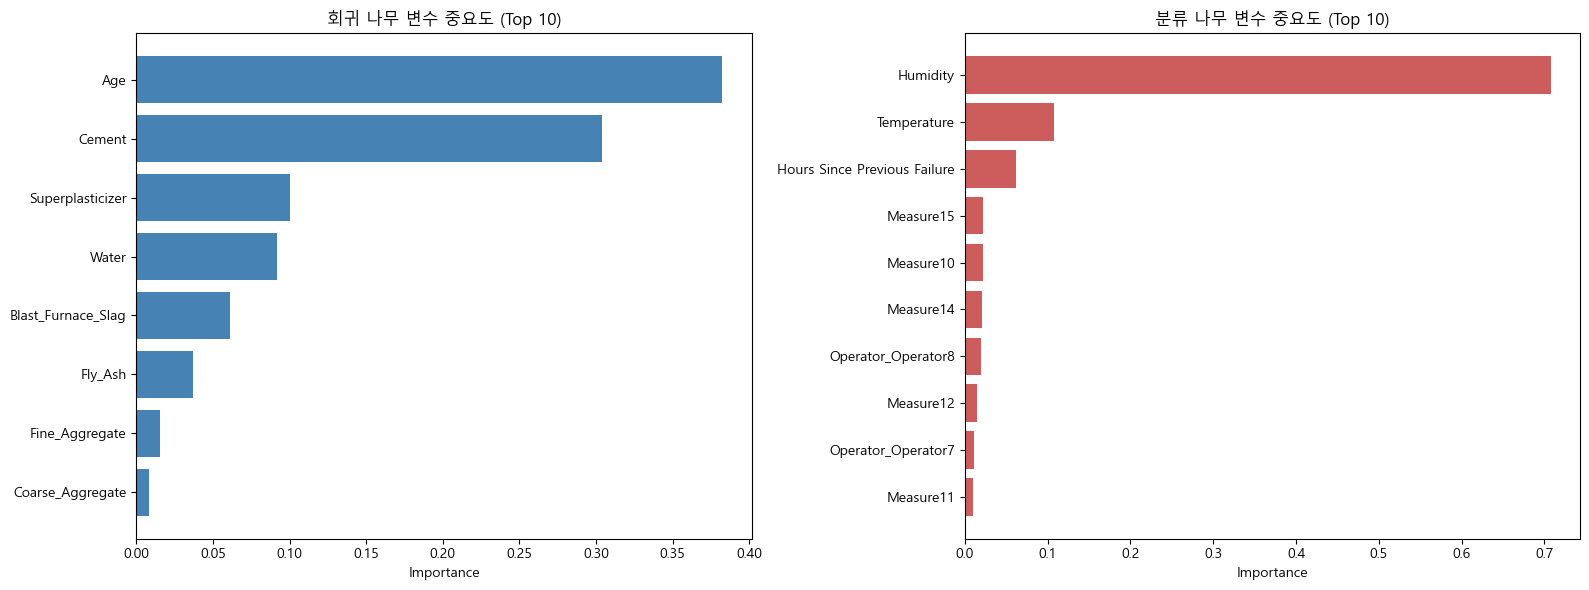

In [29]:
# 변수 중요도 시각화 (상위 10개)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_reg = imp_reg.head(10).iloc[::-1]   # 가로 막대는 아래→위 순서라 뒤집음
axes[0].barh(top_reg["Variable"], top_reg["Importance"], color="steelblue")
axes[0].set_title("회귀 나무 변수 중요도 (Top 10)")
axes[0].set_xlabel("Importance")

top_cla = imp_cla.head(10).iloc[::-1]
axes[1].barh(top_cla["Variable"], top_cla["Importance"], color="indianred")
axes[1].set_title("분류 나무 변수 중요도 (Top 10)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

### 4-3) 모델 고도화 심화

**[과제 3]** 지수는 의사결정나무 모델의 하이퍼파라미터가 많아 어떤 값을 기준으로 탐색해야 할지 고민하고 있습니다. AI와 함께 주요 하이퍼파라미터의 의미를 알아보고, 회귀 나무와 분류 나무에 적절한 탐색 범위를 설정해 보세요. 이후 적절한 하이퍼파라미터 튜닝 기법을 적용하여 모델 성능이 얼마나 개선되는지 확인해 보세요.

### 4-4) 모델 종합 비교

**[과제 4]** 지수는 오늘 회귀 및 분류 데이터셋에 대해 여러 머신러닝 모델을 구축했지만 어떤 모델을 최종적으로 선택해야 할지 고민하고 있습니다. AI와 함께 다른 실습에서 사용한 모델들의 성능을 가져와 비교해 보고, 어떤 기준으로 모델을 선택해야 하는지 고민해 보세요. 또한 가장 우수한 성능을 보인 모델은 무엇인지, 그리고 왜 해당 모델이 좋은 성능을 보였을지 데이터의 특성과 함께 해석해 보세요.